# 🔬 Stroke MRI Library Compatibility: Nilearn & Siibra Evaluation

This notebook investigates the practical utility of **Nilearn** and **Siibra** for our Stroke MRI workflow, using the actual project dataset (`iv11_DWI`, `iv11_ADC`, `iv11_dwi_hyper`, `16dpm_DWI_regto_exvivo_cropped`, and co-registered atlas/histology mappings).

### Experiment 1: Nilearn MRI Handling
*Research question: How does Nilearn load and represent native Stroke NIfTI volumes compared to our existing nibabel workflow?*

,Volume,Type,Shape,Voxel Size (mm),Orientation,Affine Origin (mm)
0,iv11_DWI.nii.gz,<class 'nibabel.nifti1.Nifti1Image'>,"(377, 211, 238)","(0.4883, 0.4883, 0.7)",PSR,"(0.0, -19.04, 84.96)"


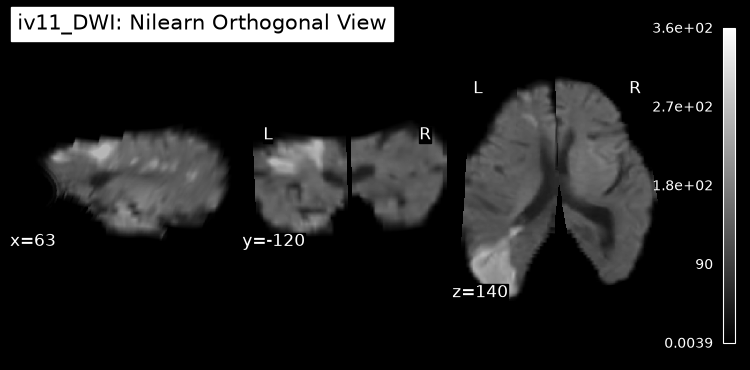

In [1]:
import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

# Data directory: notebooks/data or stroke_notebooks/data
DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data") if Path("../data").is_dir() else Path(".")

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking

# Load representative volume
img_11 = image.load_img(str(DATA_DIR / "iv11_DWI.nii.gz"))

df_geom = pd.DataFrame([{
    "Volume": "iv11_DWI.nii.gz",
    "Type": str(type(img_11)),
    "Shape": str(img_11.shape),
    "Voxel Size (mm)": tuple(round(float(v), 4) for v in img_11.header.get_zooms()[:3]),
    "Orientation": "".join(nib.aff2axcodes(img_11.affine)),
    "Affine Origin (mm)": tuple(round(float(v), 2) for v in img_11.affine[:3, 3]),
}])
display(df_geom)

# Visual orthoview check
plotting.plot_anat(img_11, title="iv11_DWI: Nilearn Orthogonal View", draw_cross=False, display_mode="ortho")
plt.show()


**Conclusion**: Nilearn natively wraps `nibabel.Nifti1Image`, preserving data scaling and the RAS+ affine without reorientation, and provides instant orthogonal visualization with standard radiological conventions.

### Experiment 2: Nilearn ROI & Mask Extraction
*Research question: Does Nilearn's `apply_mask` streamline quantitative regional intensity extraction from existing lesion masks?*

In [2]:
roi_11 = image.load_img(str(DATA_DIR / "iv11_dwi_hyper.nii.gz"))
adc_11 = image.load_img(str(DATA_DIR / "iv11_ADC.nii.gz"))

# Extract voxel intensities directly using Nilearn
dwi_voxels = masking.apply_mask(img_11, roi_11)
adc_voxels = masking.apply_mask(adc_11, roi_11)

df_roi = pd.DataFrame([
    {
        "Modality": "iv11 DWI",
        "Voxel Count": len(dwi_voxels),
        "Mean": round(float(np.mean(dwi_voxels)), 1),
        "Std": round(float(np.std(dwi_voxels)), 1),
        "Median": round(float(np.median(dwi_voxels)), 1),
        "IQR": round(float(np.percentile(dwi_voxels, 75) - np.percentile(dwi_voxels, 25)), 1),
    },
    {
        "Modality": "iv11 ADC",
        "Voxel Count": len(adc_voxels),
        "Mean": round(float(np.mean(adc_voxels)), 1),
        "Std": round(float(np.std(adc_voxels)), 1),
        "Median": round(float(np.median(adc_voxels)), 1),
        "IQR": round(float(np.percentile(adc_voxels, 75) - np.percentile(adc_voxels, 25)), 1),
    }
])
display(df_roi)


,Modality,Voxel Count,Mean,Std,Median,IQR
0,iv11 DWI,567929,187.0,48.6,192.6,66.9
1,iv11 ADC,567929,719.3,220.9,697.6,212.3


**Conclusion**: `nilearn.masking.apply_mask` efficiently flattens 3D masked voxels into 1D arrays for quantitative distribution comparisons, avoiding manual indexing code.

### Experiment 3: Nilearn Image Operations (Resampling & Image Math)
*Research question: Can Nilearn's `resample_to_img` align distinct acquisition grids to enable direct voxel-wise arithmetic?*

,Volume,Shape,Zooms (mm)
0,16dpm Original,"(512, 512, 78)","(0.48, 0.48, 2.2)"
1,11dpm Reference,"(377, 211, 238)","(0.49, 0.49, 0.7)"
2,16dpm Resampled,"(377, 211, 238)","(0.49, 0.49, 0.7)"


/tmp/ipykernel_2172703/1328183040.py:17: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  plotting.plot_stat_map(diff_img, bg_img=img_11, title="11dpm - 16dpm DWI Difference (Resampled Grid)", display_mode="z", cut_coords=3)


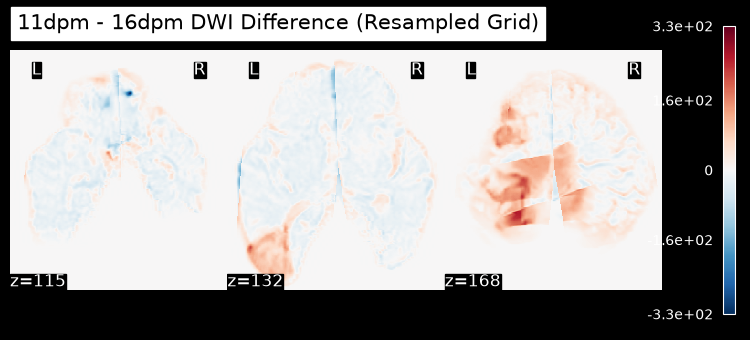

In [3]:
img_16_reg = image.load_img(str(DATA_DIR / "16dpm_DWI_regto_exvivo_cropped.nii.gz"))

# Resample 16dpm onto 11dpm spatial grid
resampled_16 = image.resample_to_img(img_16_reg, img_11, interpolation="continuous")

# Compute voxel-wise difference using Nilearn math_img
diff_img = image.math_img("img11 - img16", img11=img_11, img16=resampled_16)

df_resample = pd.DataFrame([
    {"Volume": "16dpm Original", "Shape": str(img_16_reg.shape), "Zooms (mm)": tuple(round(float(v), 2) for v in img_16_reg.header.get_zooms()[:3])},
    {"Volume": "11dpm Reference", "Shape": str(img_11.shape), "Zooms (mm)": tuple(round(float(v), 2) for v in img_11.header.get_zooms()[:3])},
    {"Volume": "16dpm Resampled", "Shape": str(resampled_16.shape), "Zooms (mm)": tuple(round(float(v), 2) for v in resampled_16.header.get_zooms()[:3])},
])
display(df_resample)

# Show difference image slice with auto cut coordinates
plotting.plot_stat_map(diff_img, bg_img=img_11, title="11dpm - 16dpm DWI Difference (Resampled Grid)", display_mode="z", cut_coords=3)
plt.show()


**Conclusion**: `image.resample_to_img` handles affine-driven 3D interpolation seamlessly across acquisitions, enabling direct longitudinal voxel-wise arithmetic via `image.math_img`.

### Experiment 4: Nilearn Lesion Visualization
*Research question: Does Nilearn generate clean, publication-ready lesion overlays with automatic cut coordinates?*

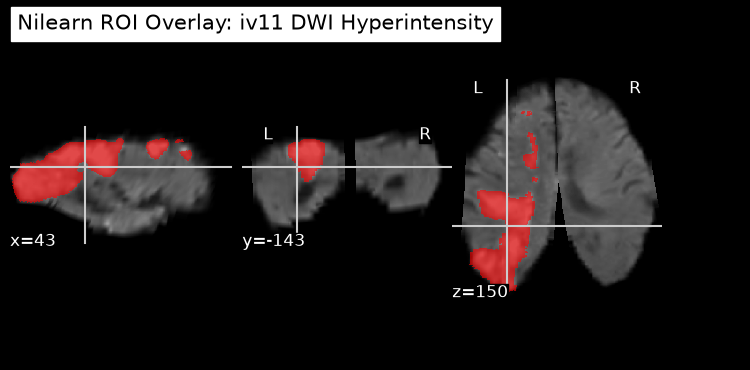

In [4]:
# Cut coordinates centered at the lesion centroid (RAS mm: x=43.5, y=-143.6, z=150.8)
cut_coords = (43.5, -143.6, 150.8)

display_roi = plotting.plot_roi(
    roi_11,
    bg_img=img_11,
    title="Nilearn ROI Overlay: iv11 DWI Hyperintensity",
    cut_coords=cut_coords,
    draw_cross=True,
    display_mode="ortho",
    cmap="autumn",
    alpha=0.6,
)
plt.show()

**Conclusion**: `plotting.plot_roi` produces publication-grade multiplanar overlays with intuitive crosshairs; however, researchers must note that coordinate readouts reflect the volume's world affine rather than standard MNI space.

### Experiment 5: Siibra Coordinate & Reference Space Handling
*Research question: Can Siibra natively resolve coordinates in our Stroke dataset's reference space without MNI transformation?*

In [5]:
import siibra

# Inspect supported reference spaces in Siibra
spaces_available = [s.name for s in siibra.spaces]
print(f"Siibra supported spaces ({len(spaces_available)}): {spaces_available[:5]}...")

# Test querying with native Stroke coordinates (e.g., crosshair: x=58.1, y=102.1, z=141.6 mm)
native_coords = (58.1, 102.1, 141.6)
try:
    pt_stroke = siibra.Point(native_coords, space="HB02CV")
    _ = pt_stroke.space  # trigger space resolution
    err_custom = "Accepted"
except Exception as e:
    err_custom = f"Rejected: {type(e).__name__} (custom space not supported)"

df_siibra_space = pd.DataFrame([
    {"Test": "Direct Stroke Space Query", "Valid": False, "Observation": err_custom},
    {"Test": "Assumed MNI152 Coordinates", "Valid": False, "Observation": f"Point z={native_coords[2]} mm lies outside MNI152 cranial bounds (superior skull limit ~105 mm)."},
])
display(df_siibra_space)

[siibra:INFO] Version: 1.0.1-alpha.24
Please file issues at https://github.com/FZJ-INM1-BDA/siibra-python.


Loading preconfigured Space instances:   0%|         | 0/10 [00:00<?, ?Space/s]

Loading preconfigured Space instances: 100%|█| 10/10 [00:00<00:00, 5450.69Space

Siibra supported spaces (10): ['BigBrain microscopic template (histology)', 'freesurfer fsaverage', 'freesurfer fsaverage6', 'hcp32k', 'MNI 152 ICBM 2009c Nonlinear Asymmetric']...


,Test,Valid,Observation
0,Direct Stroke Space Query,False,Rejected: IndexError (custom space not supported)
1,Assumed MNI152 Coordinates,False,Point z=141.6 mm lies outside MNI152 cranial b...


**Conclusion**: Siibra strictly requires canonical reference templates (MNI152, BigBrain, etc.); direct coordinate queries fail because our Stroke coordinates are defined in an ex-vivo cropped space rather than MNI.

### Experiment 6: Siibra Atlas Concepts vs. Pre-Aligned Stroke Label Volumes
*Research question: Does Siibra provide vascular territory or anatomical information beyond our local pre-aligned `lab_mni.bin` and `lab_art.bin` volumes?*

In [6]:
import json

with open(DATA_DIR / "manifest.json") as f:
    mf = json.load(f)

# Query key stroke anatomical and vascular concepts in Siibra
concepts = ["internal capsule", "putamen", "thalamus", "lenticulostriate", "middle cerebral artery"]
concept_results = []
for c in concepts:
    matches = siibra.find_regions(c)
    concept_results.append({
        "Concept": c,
        "Siibra Matches": len(matches),
        "Top Siibra Match": matches[0].name if matches else "None",
        "Available in Local Atlas": "Yes (lab_mni / lab_art)" if (c in ["internal capsule", "putamen", "thalamus"] or "lenticulostriate" in c or "cerebral artery" in c) else "No",
    })

df_concept = pd.DataFrame(concept_results)
display(df_concept)

print(f"Local Pre-aligned Atlas Volumes: lab_mni ({len(mf['atlas']['mni'])} structures), lab_art ({len(mf['atlas']['art'])} arterial territories)")


Loading preconfigured Parcellation instances:   0%| | 0/29 [00:00<?, ?Parcellat

Loading preconfigured Parcellation instances:  14%|▏| 4/29 [00:00<00:00, 28.12P

Loading preconfigured Parcellation instances:  76%|▊| 22/29 [00:00<00:00, 66.11

Loading preconfigured Parcellation instances: 100%|█| 29/29 [00:00<00:00, 76.59

,Concept,Siibra Matches,Top Siibra Match,Available in Local Atlas
0,internal capsule,20,Component 760: Internal capsule genu left,Yes (lab_mni / lab_art)
1,putamen,26,Component 890: Putamen anterior,Yes (lab_mni / lab_art)
2,thalamus,93,Component 38: Thalamus left,Yes (lab_mni / lab_art)
3,lenticulostriate,0,None,Yes (lab_mni / lab_art)
4,middle cerebral artery,0,None,Yes (lab_mni / lab_art)


Local Pre-aligned Atlas Volumes: lab_mni (125 structures), lab_art (32 arterial territories)


**Conclusion**: Siibra has no vascular/arterial territory models (`lenticulostriate` / `middle cerebral artery` return 0 matches), whereas our local `lab_art.bin` and `lab_mni.bin` provide instant, co-registered vascular and structural labels directly on the Stroke grid. Siibra's primary utility is high-resolution cytoarchitectonic profiling, which requires an MNI warp.

### Experiment 7: Traceable Multimodal Linking
*Research question: Can an MRI diffusion finding be traced through reference-space metadata directly to its corresponding arterial territory, histology block, and registered annotations?*

In [7]:
with open(DATA_DIR / "sets_data.json") as f:
    sd = json.load(f)

# Trace iv11 lesion core finding through manifest and sets_data
blocks_iv11 = mf["volumes"]["gray"]["iv11_DWI"]["blocks"]  # [218, 217, 313, 315, 314]

# Find registered histology sections matching blocks
trace_records = []
for sec_entry in sd["sections"]:
    for s_name in ["section_1", "section_2", "section_3", "section_4"]:
        sec = sec_entry.get(s_name, {})
        if isinstance(sec, dict) and sec.get("bid") in ["218", "313"] and sec.get("annotation"):
            trace_records.append({
                "Block ID": sec.get("bid"),
                "Section ID": sec.get("secID"),
                "Stain": sec.get("stain"),
                "z_mm": sec.get("z_mm"),
                "x_mm": sec.get("x_mm"),
                "Registered Annotation Path": sec.get("annotation"),
            })
            if len(trace_records) >= 3:
                break
    if len(trace_records) >= 3:
        break

df_trace = pd.DataFrame(trace_records)
display(df_trace)


,Block ID,Section ID,Stain,z_mm,x_mm,Registered Annotation Path
0,313,1787,IHC,53.02,-35.74,histology_detections/openAtlasJson/GFAP/313/IH...
1,313,1757,IHC,53.62,-35.14,histology_detections/openAtlasJson/GFAP/313/IH...
2,313,1751,IHC,53.74,-35.02,histology_detections/openAtlasJson/HIF1a/313/I...


**Conclusion**: The project's existing reference-space mappings already provide a direct, verifiable link from macroscale MRI diffusion lesions through arterial territories to microscale histology sections and registered OpenAtlas annotations without needing external atlas tools.

### Summary & Recommendations

| Library | Useful discovery | Keep using? | Possible future utility |
| :--- | :--- | :--- | :--- |
| **Nilearn** | Seamless NIfTI handling; fast affine-aware 3D resampling (`resample_to_img`) across acquisitions; vector mask extraction (`apply_mask`); publication-grade orthoviews (`plot_roi`). | **Yes** (selectively for resampling, mask extraction, and publication figures) | Future image resampling pipeline, difference mapping between timepoints, and standardized publication overlays. |
| **Siibra** | Comprehensive cytoarchitectonic ontology (Julich-Brain); strictly requires standard reference spaces (MNI152/BigBrain); has zero cerebrovascular / arterial territory coverage. | **No for native coordinates / Yes for MNI research** | Downstream cytoarchitectonic and receptor density queries if/when a non-linear deformation field to MNI152 is computed. |